# 05 · Local multilingual-teacher pilot

**Question:** with one fixed model and the same four original-language training reports, how does an anatomy-specific target contract change candidate assertions?

This is a small operational and supervision comparison, **not clinical accuracy or image-model AUC**. Both arms may be wrong. No generated target is approved for training. Expert labels and matching report groups remain sealed.

Prerequisite: `python research/teacher/run.py prepare` passed. Use **RSNA Knee - audit**, restart kernel and run all. No new environment, image download, GPU, account password or remote model endpoint is required.

The first worker permits two synthetic canaries and eight real-report arm calls, with a 900-second outer guard. Failure stops additional real-report calls. The second worker reuses the checkpoint with zero new model calls. A blocked result is displayed and packaged honestly.

Each chart cell writes **a separate saved PNG as well as Plotly**, and exports HTML/JSON. Save, close and reopen this notebook after completion. References and limitations: `research/teacher/SOURCES.md` and `REVIEW_PROTOCOL.md`.


In [1]:
from pathlib import Path
import sys, json
ROOT = Path.home() / "rsna-knee-abnormality-detection"
assert Path(sys.prefix).resolve() == (ROOT / ".venv").resolve(), "Select RSNA Knee - audit"
STAGE = ROOT / "research/teacher"
sys.path.insert(0, str(STAGE))
from teacher_common import require_tests, previous, read_json, WORK
from teacher_pipeline import current_run
from teacher_plots import display_saved, finalize_figures
import importlib.util
entry_spec = importlib.util.spec_from_file_location("rsna_teacher_entry", STAGE / "run.py")
entry = importlib.util.module_from_spec(entry_spec)
entry_spec.loader.exec_module(entry)
tests = require_tests()
previous()
print("Current teacher tests passed:", tests["tests"])
print("Existing 58 expert studies and 4 report-overlap studies remain sealed.")
print("No report text, quote or patient identifier will be displayed in this notebook.")


Current teacher tests passed: 59
Existing 58 expert studies and 4 report-overlap studies remain sealed.
No report text, quote or patient identifier will be displayed in this notebook.


## Bounded inference and exact reuse

The public model and CPU runtime were already downloaded during preparation. The worker starts a temporary authenticated server on **127.0.0.1**, checks fabricated cases, then permits the four-report comparison. No report is sent to Hugging Face, Kaggle, or a hosted model API. The model server is closed when the worker exits.

A canary or evidence-format failure yields a **blocked** outcome. It does not justify a larger model run or automatically retried prompts. The charts will record the limited evidence actually obtained.


In [2]:
first = entry.launch_analysis()
second = entry.launch_analysis()
assert second["key"] == first["key"]
assert second["status"] == "reused_verified" and second["new_model_calls"] == 0
DIRECTORY, summary = current_run()
print("Pilot outcome:", summary["status"])
print("Successful common paired reports:", summary["paired_reports"])
print("Second invocation: zero new model calls; saved evidence reused.")
print("Training targets approved:", summary["training_targets_approved"])


{"utc": "2026-09-14T19:06:54.737894+00:00", "event": "inference_started", "elapsed_seconds": 5.538, "rss_gib": 0.041, "call_alias": "C01", "arm": "domain_contract"}
{"utc": "2026-09-14T19:08:07.122397+00:00", "event": "inference_finished", "elapsed_seconds": 77.922, "rss_gib": 0.041, "call_alias": "C01", "status": "valid", "elapsed_call_seconds": 72.368}
{"utc": "2026-09-14T19:08:07.124000+00:00", "event": "inference_started", "elapsed_seconds": 77.924, "rss_gib": 0.041, "call_alias": "C02", "arm": "domain_contract"}
{"utc": "2026-09-14T19:09:22.076363+00:00", "event": "inference_finished", "elapsed_seconds": 152.876, "rss_gib": 0.041, "call_alias": "C02", "status": "canary_failed", "elapsed_call_seconds": 74.935}
{"utc": "2026-09-14T19:09:22.338920+00:00", "event": "teacher_pilot_recorded", "elapsed_seconds": 153.139, "rss_gib": 0.044, "outcome": "blocked_canary", "new_model_calls": 2, "reused_calls": 0}
{"utc": "2026-09-14T19:09:29.943279+00:00", "event": "whole_pilot_reused_verified

## 01. Earlier lexical coverage

Counts, assignment changes and software checks are not evidence of clinical accuracy or AUC improvement.


**Earlier lexical pilot: binary candidate coverage by finding**

330 of 3,072 cells were binary in the prior 256-report sample. Coverage does not measure correctness.

Outcome: `blocked_canary`; common paired reports: 0

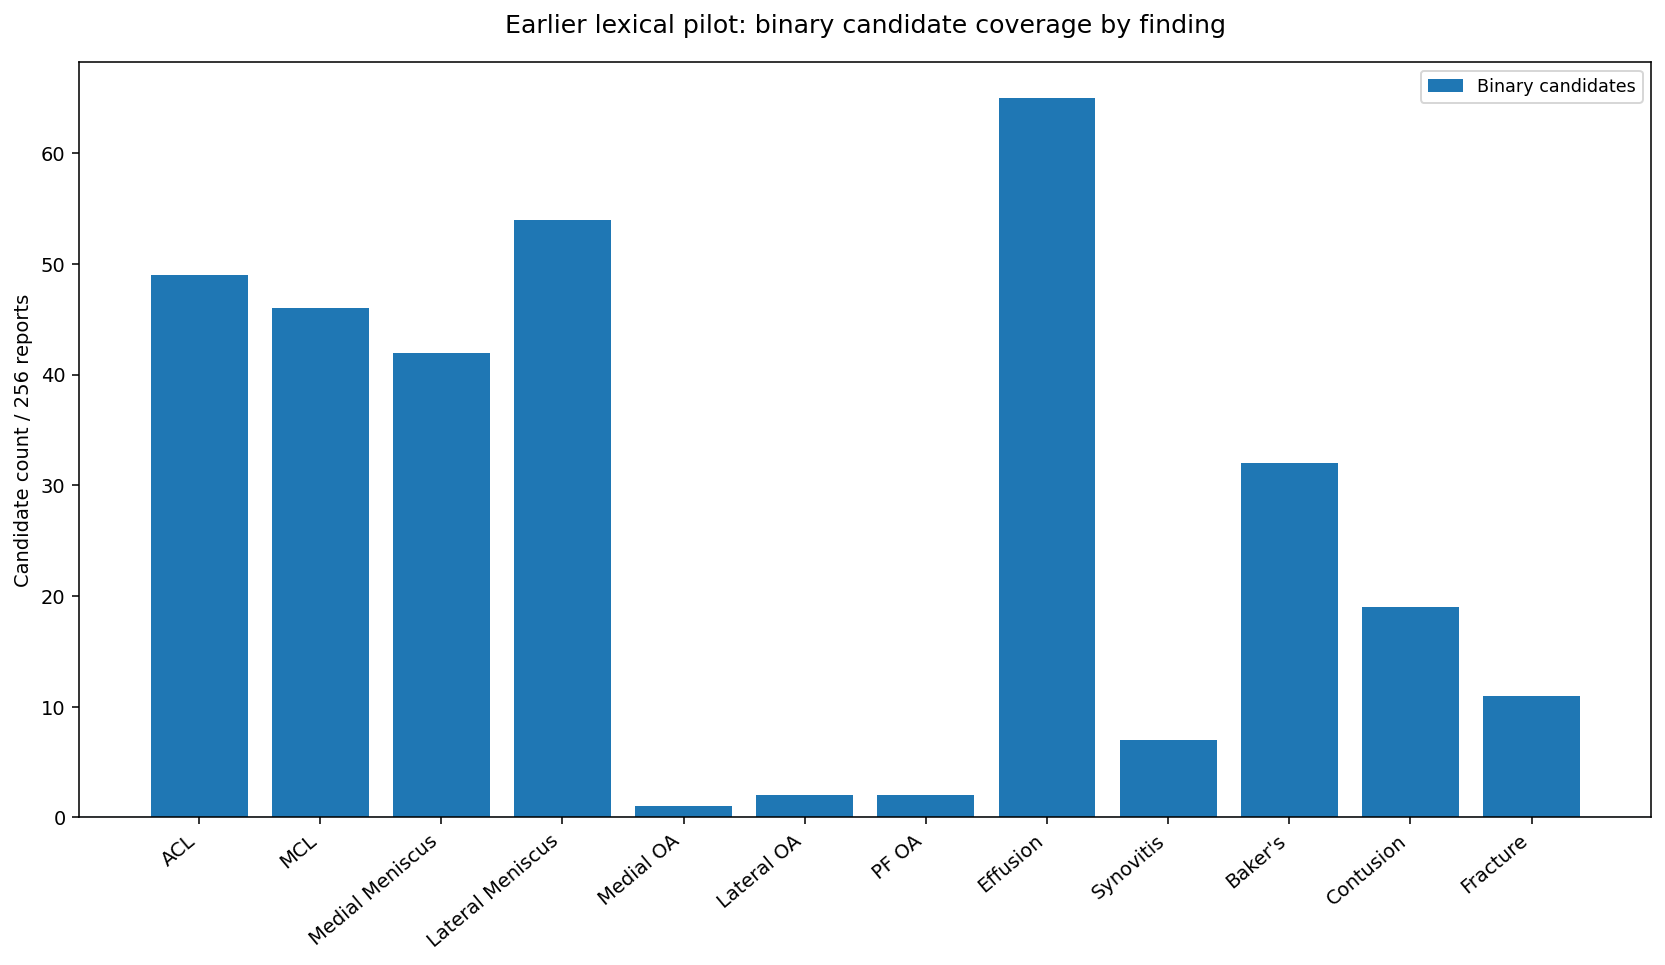

In [3]:
display_saved(1)


## 02. Selected report scripts

Counts, assignment changes and software checks are not evidence of clinical accuracy or AUC improvement.


**Teacher pilot: selected training-report script presence**

Sampling favors distinct scripts where available. Script is not language identity; four reports are not representative.

Outcome: `blocked_canary`; common paired reports: 0

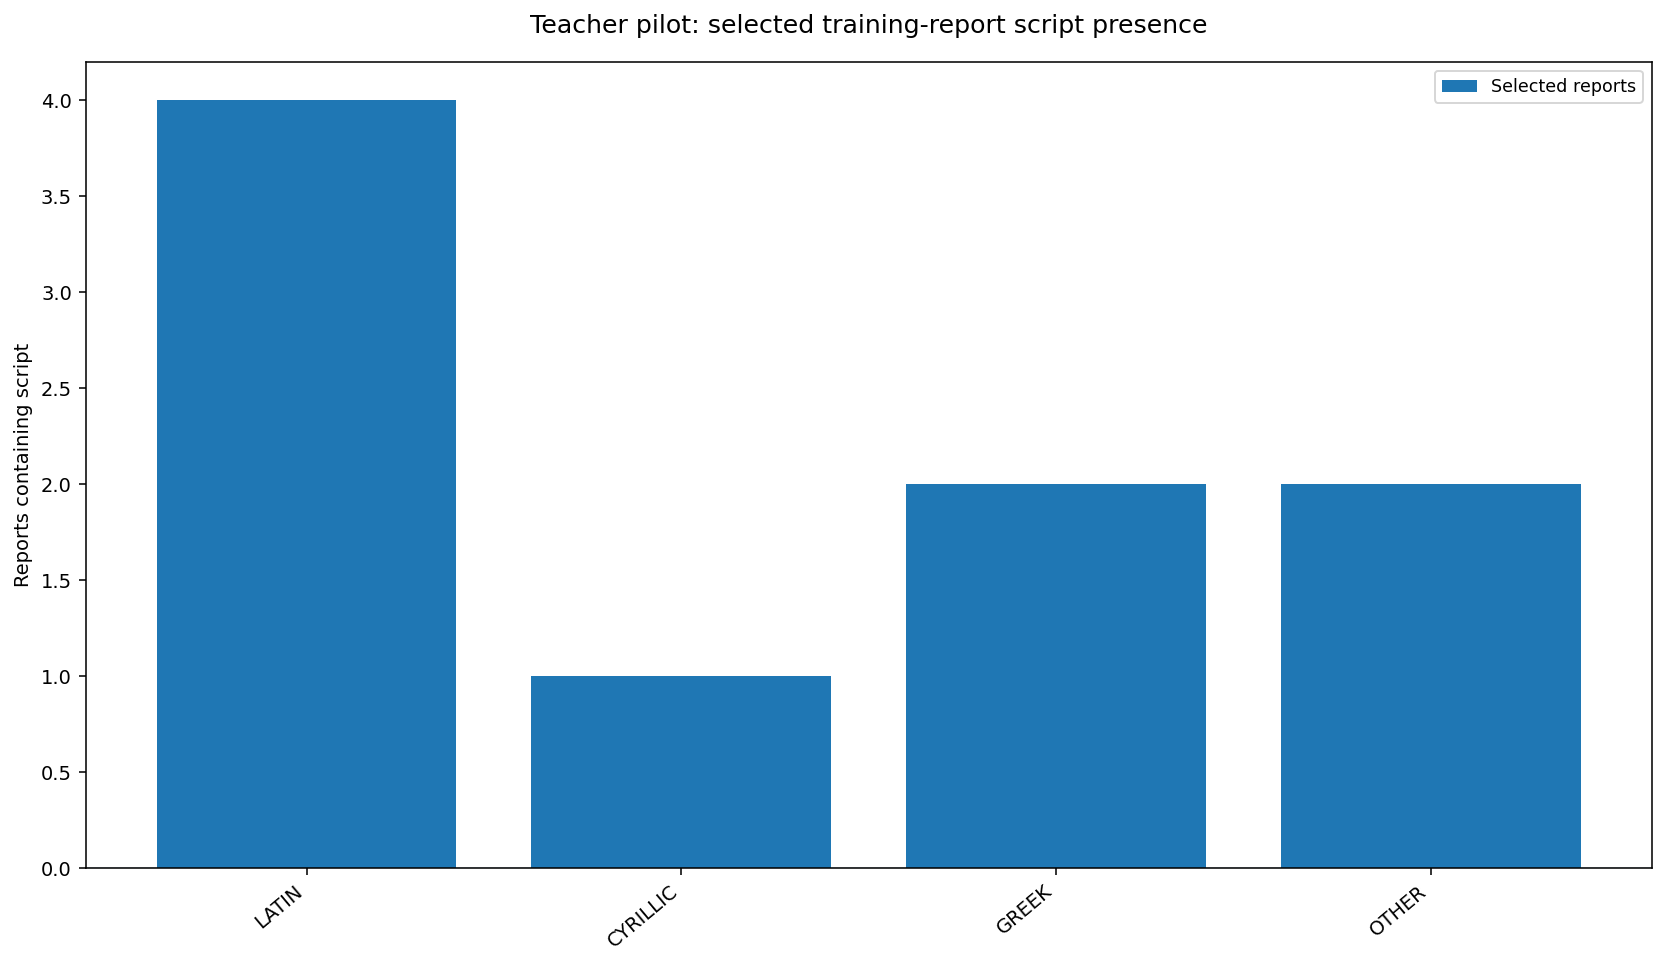

In [4]:
display_saved(2)


## 03. Synthetic operational checks

Counts, assignment changes and software checks are not evidence of clinical accuracy or AUC improvement.


**Synthetic operational checks: exact expected states, not clinical accuracy**

English and Spanish fabricated cases test a narrow execution contract. Unrun cases remain blank, not failed.

Outcome: `blocked_canary`; common paired reports: 0

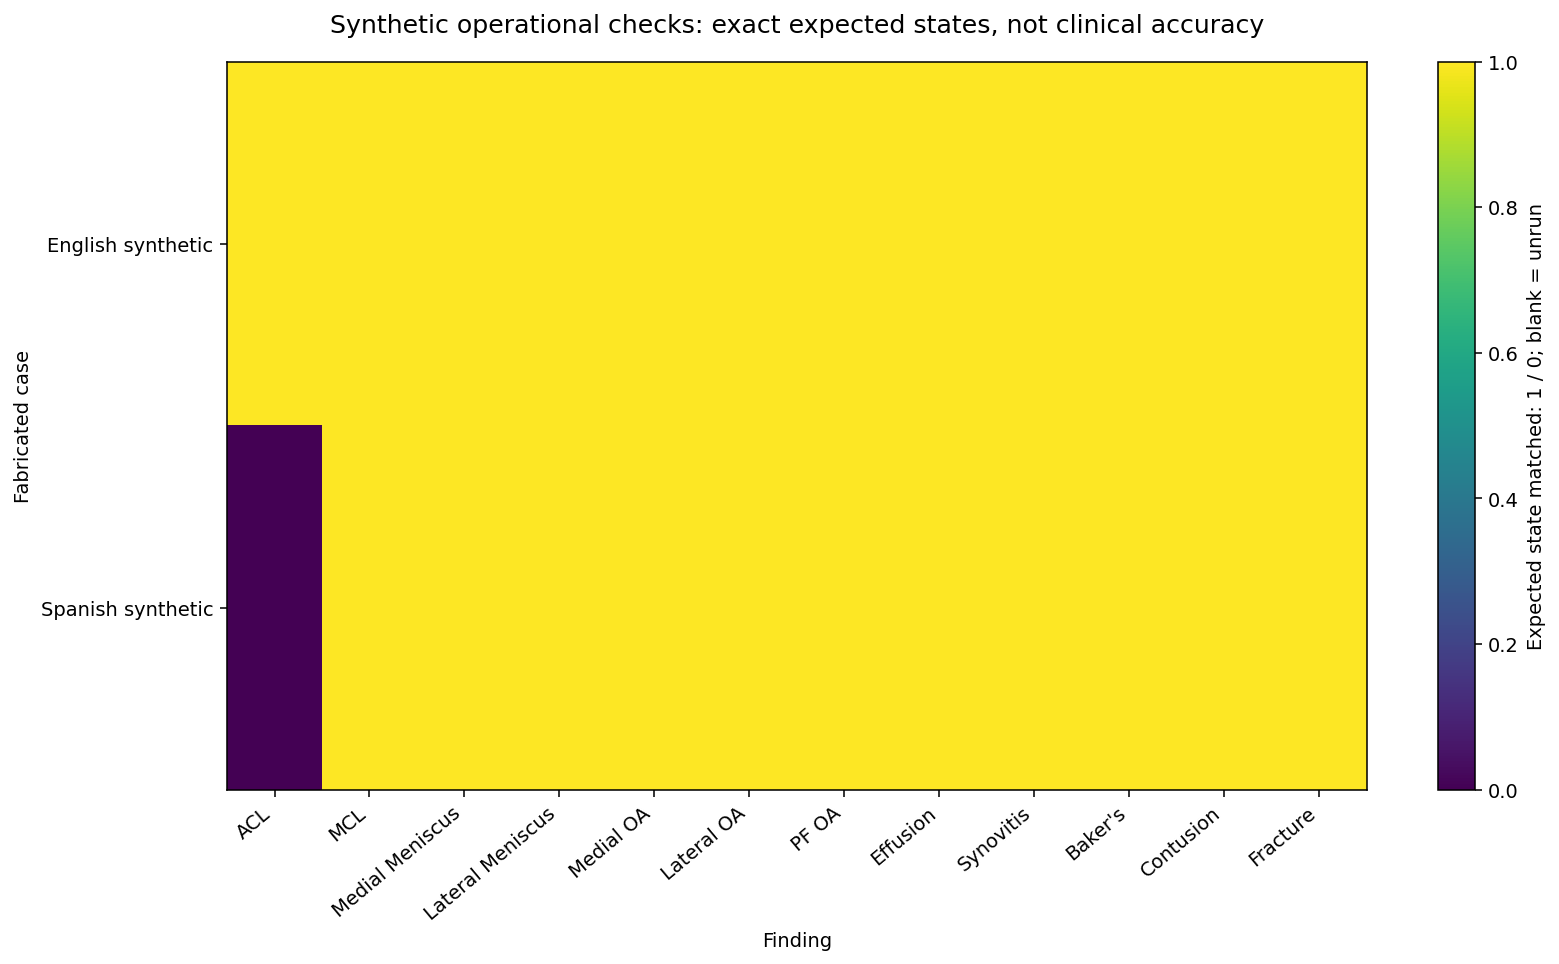

In [5]:
display_saved(3)


## 04. Completion and paired denominators

Counts, assignment changes and software checks are not evidence of clinical accuracy or AUC improvement.


**Teacher completion: same four planned reports per prompt arm**

Invalid output stops additional real-report inference; successful subsets must not be compared with different denominators.

Outcome: `blocked_canary`; common paired reports: 0

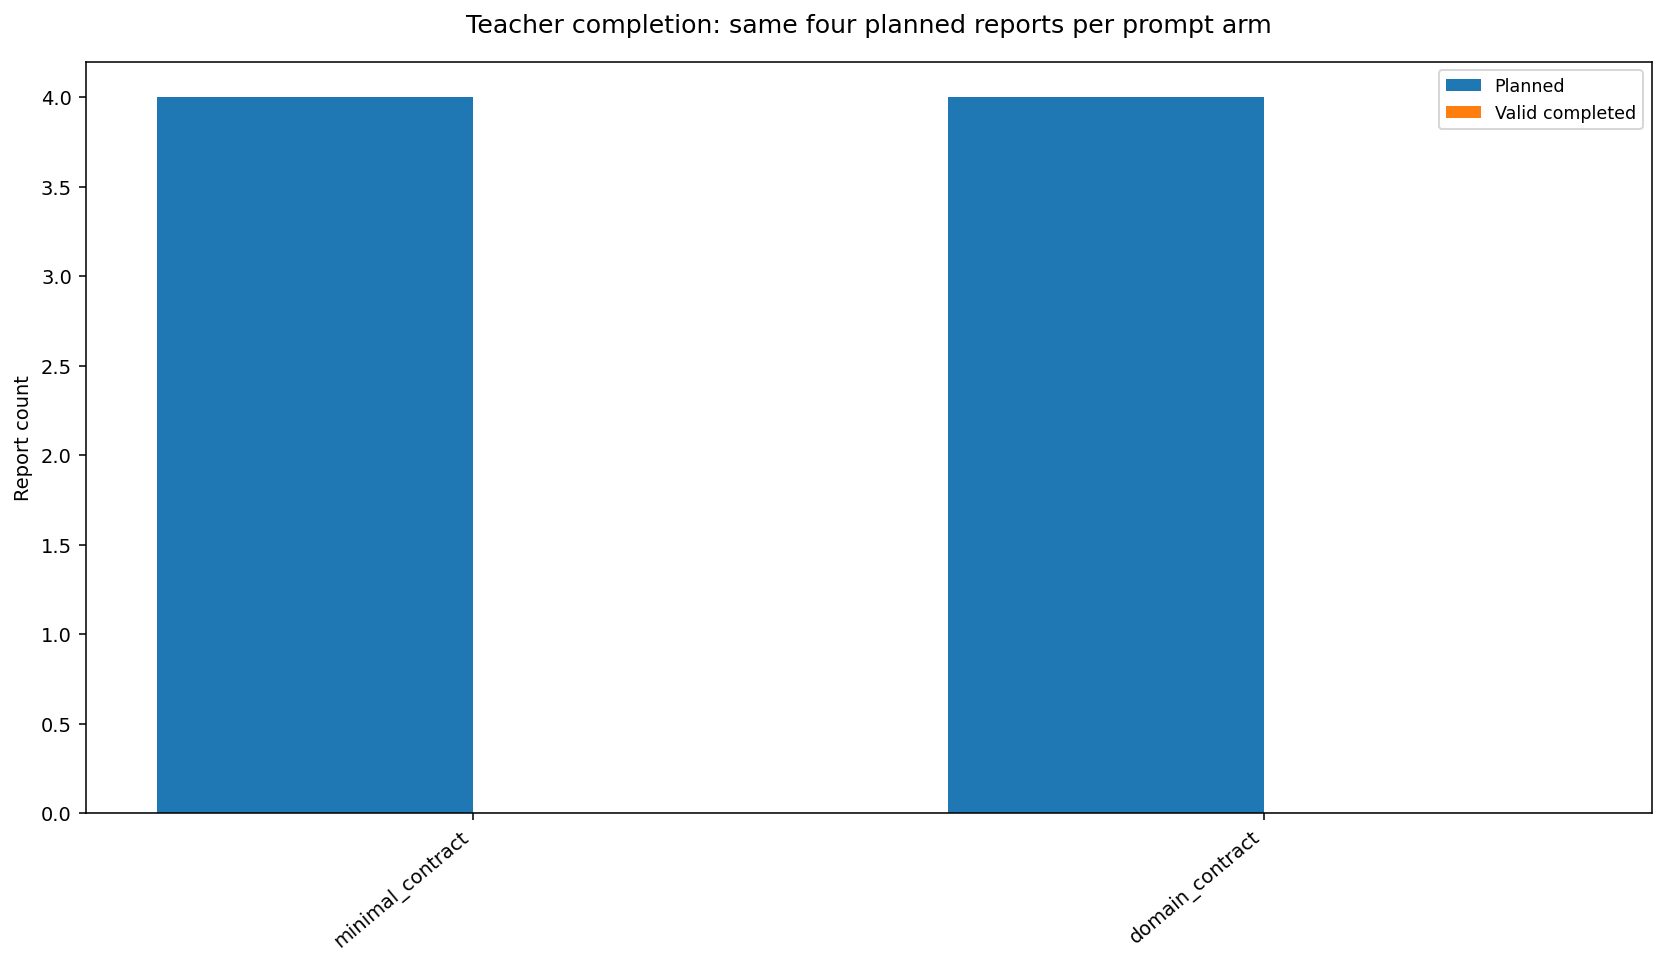

In [6]:
display_saved(4)


## 05. Binary candidates on common reports

Counts, assignment changes and software checks are not evidence of clinical accuracy or AUC improvement.


**Binary candidate counts on common successful reports only**

All series use exactly the intersection of successfully processed reports. These are label candidates, not ground truth.

Outcome: `blocked_canary`; common paired reports: 0

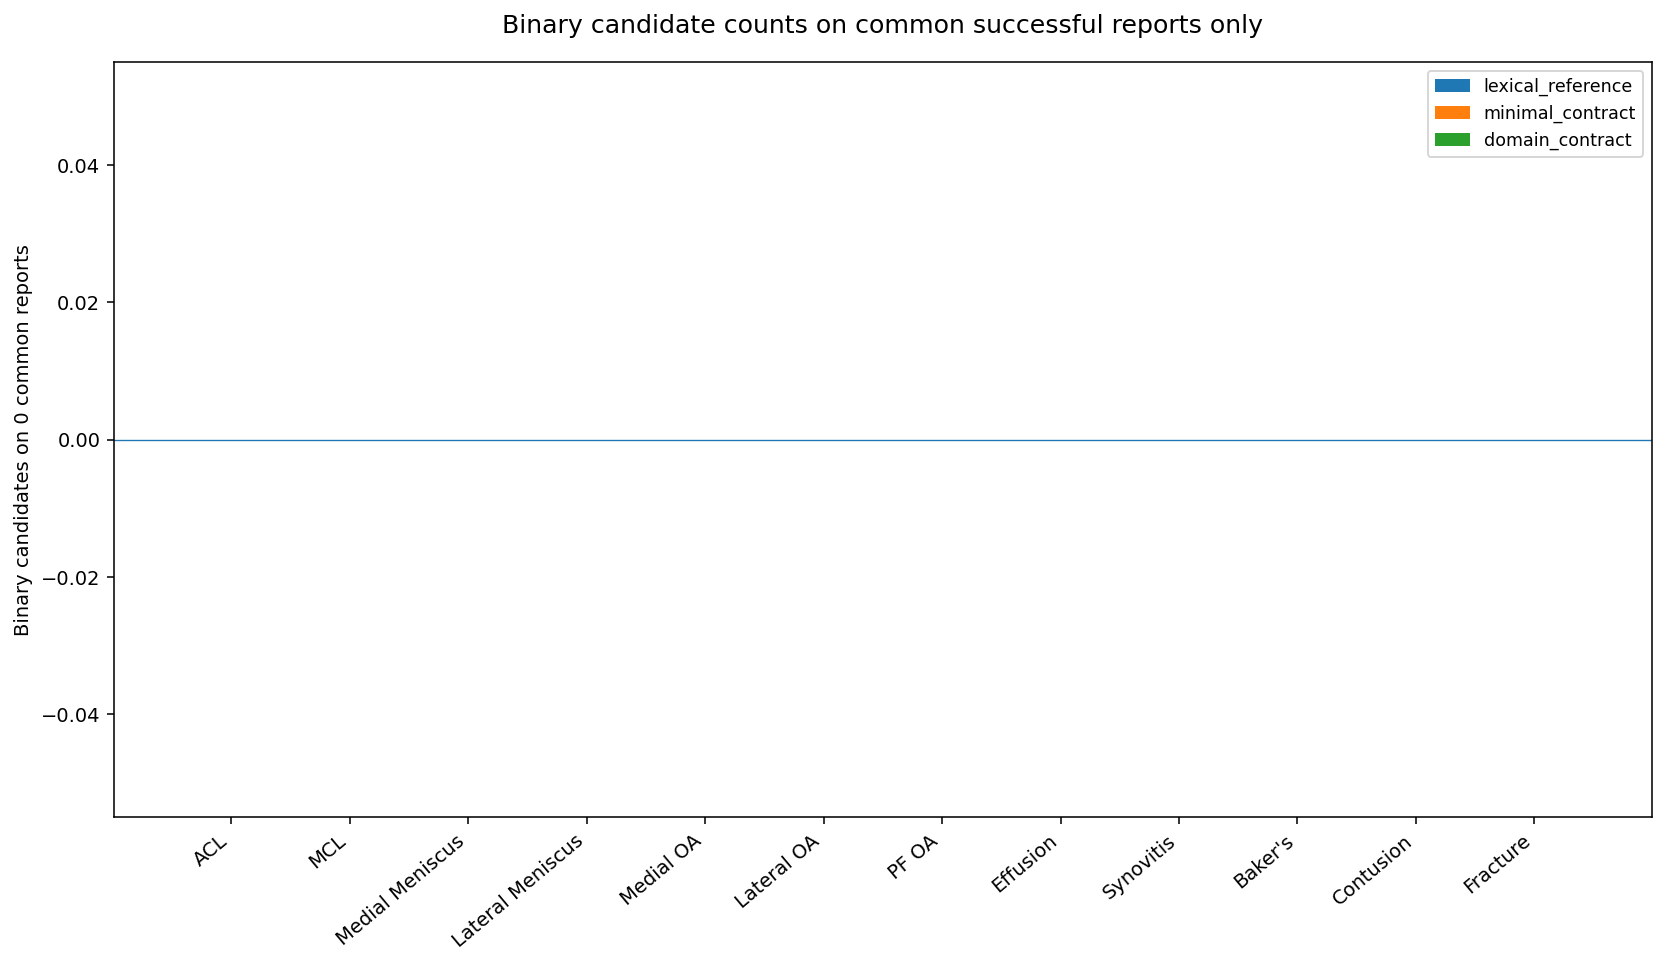

In [7]:
display_saved(5)


## 06. Effect of anatomy definitions

Counts, assignment changes and software checks are not evidence of clinical accuracy or AUC improvement.


**Prompt-definition sensitivity: paired state disagreements**

The same model, decoder and reports are used. A changed state does not establish an improvement.

Outcome: `blocked_canary`; common paired reports: 0

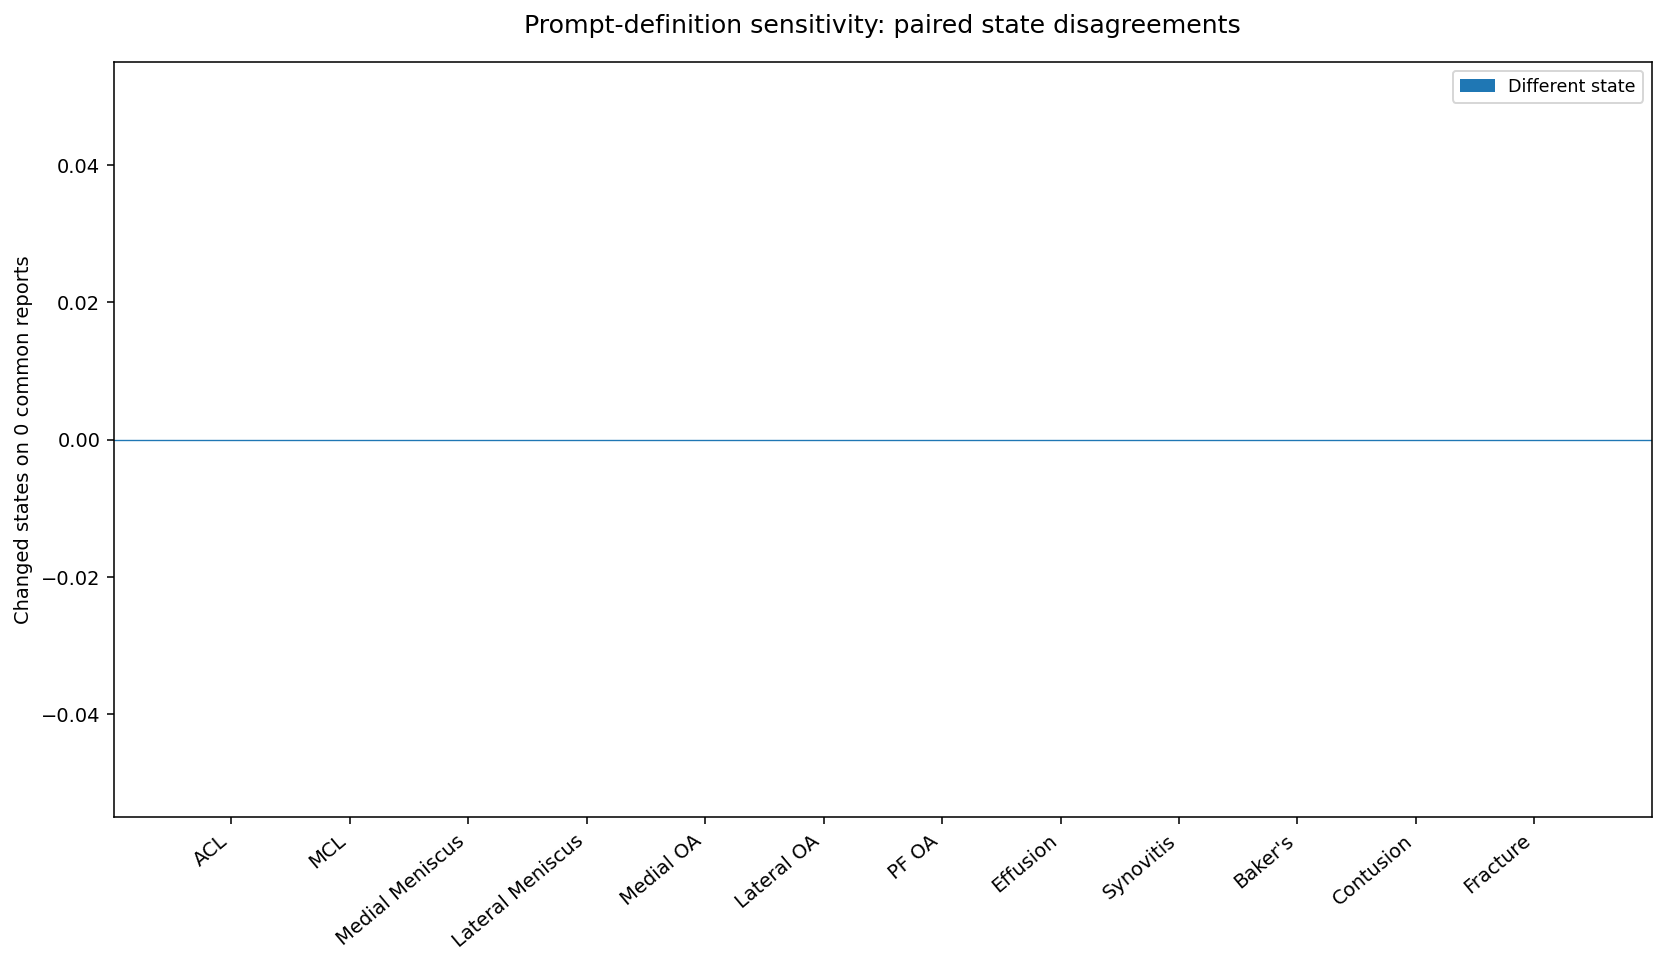

In [8]:
display_saved(6)


## 07. Explicit negative candidates

Counts, assignment changes and software checks are not evidence of clinical accuracy or AUC improvement.


**Explicit negative candidates on the matched reports**

An explicit negative needs a verbatim quote. The validator does not prove that the quote entails the conclusion.

Outcome: `blocked_canary`; common paired reports: 0

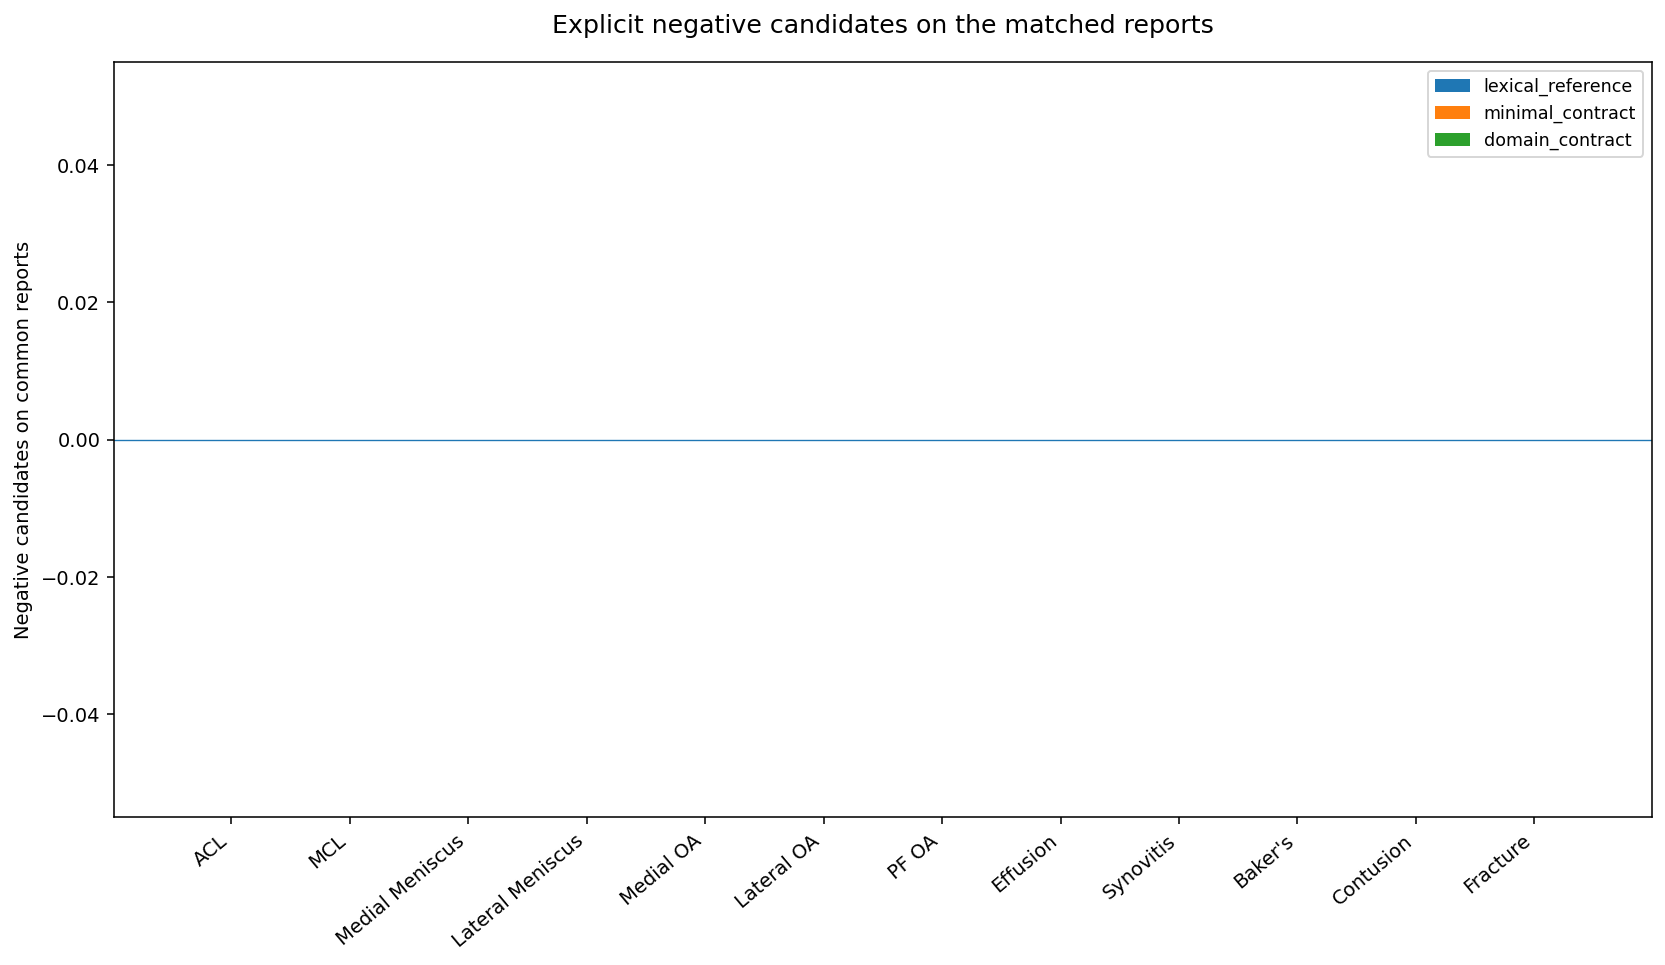

In [9]:
display_saved(7)


## 08. Abstention and assertion states

Counts, assignment changes and software checks are not evidence of clinical accuracy or AUC improvement.


**Domain-contract assertion states: missing is not negative**

Uncertainty, conflict, history-only and unmentioned remain nonbinary. Do not train an image model on these outputs yet.

Outcome: `blocked_canary`; common paired reports: 0

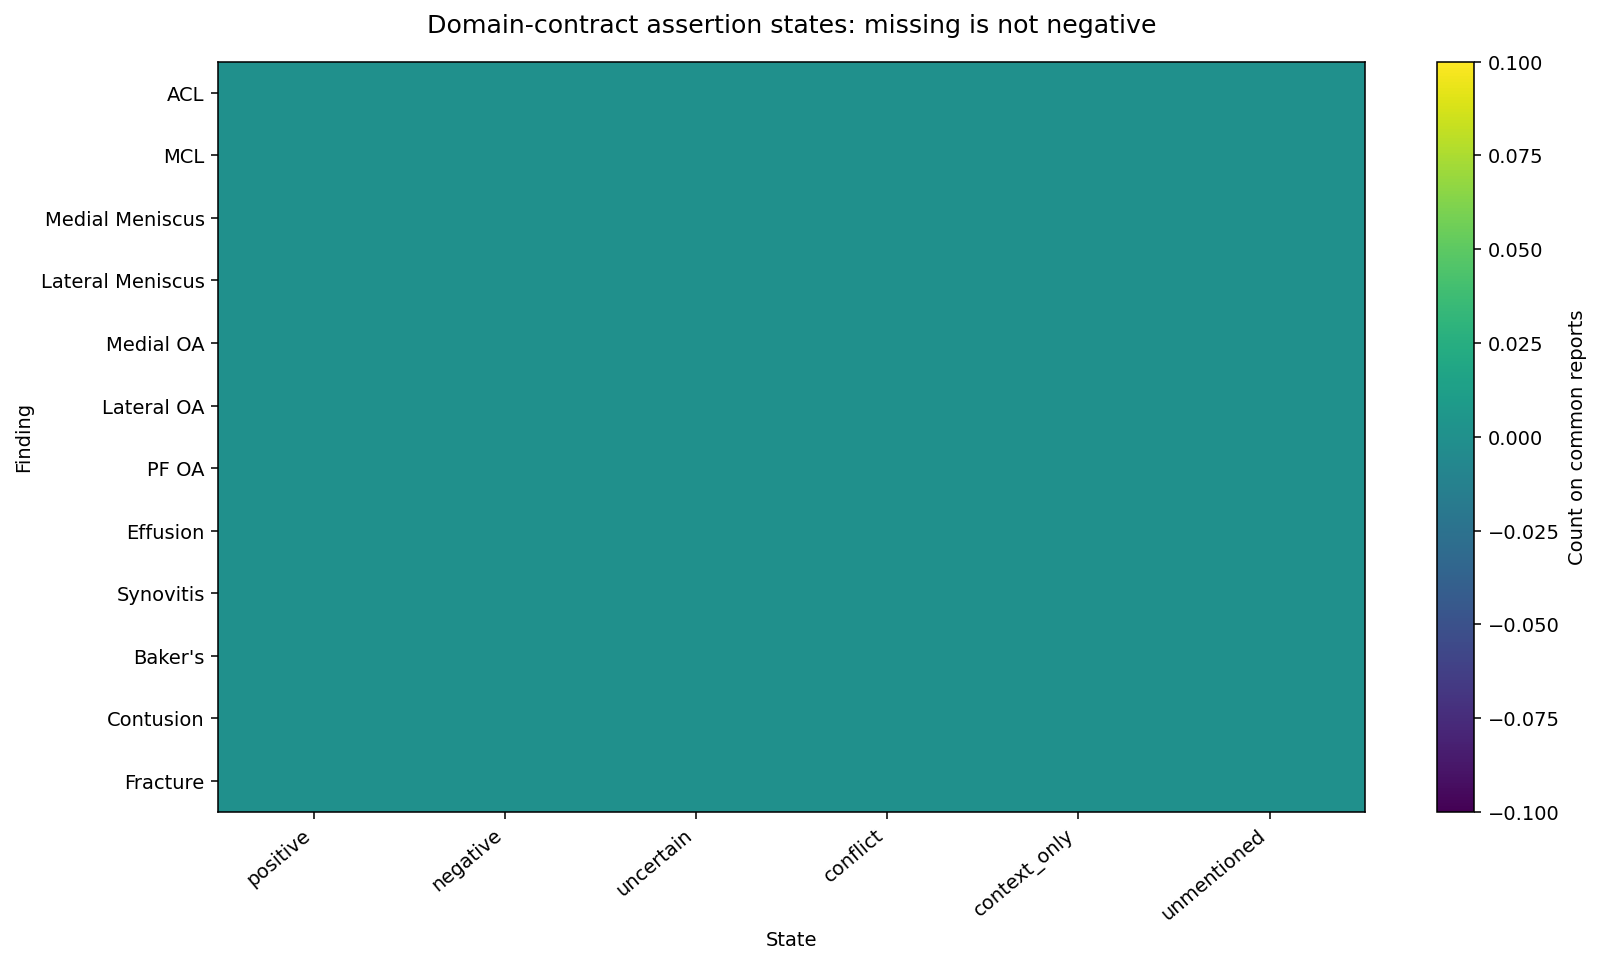

In [10]:
display_saved(8)


## 09. Output-contract failures

Counts, assignment changes and software checks are not evidence of clinical accuracy or AUC improvement.


**Output-contract rejections: evidence validity is not entailment**

Strict schema and quote checks can catch malformed outputs, not all semantic or multilingual mistakes.

Outcome: `blocked_canary`; common paired reports: 0

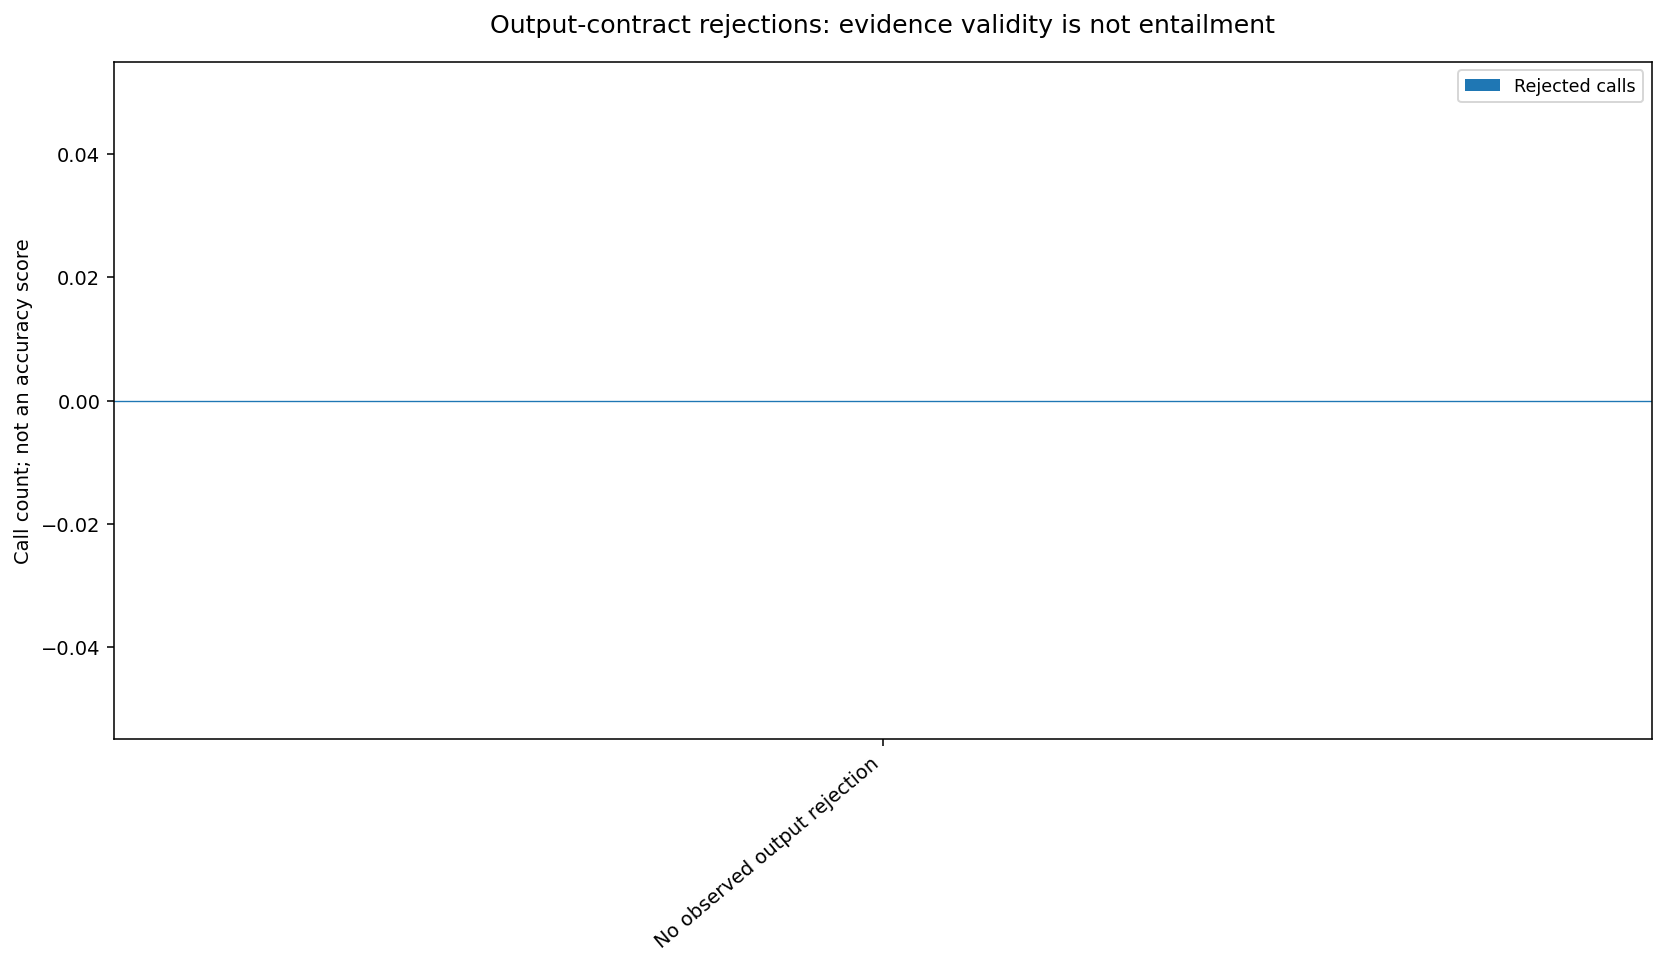

In [11]:
display_saved(9)


## 10. Token budget

Counts, assignment changes and software checks are not evidence of clinical accuracy or AUC improvement.


**Tokens used in real-report inference by prompt arm**

Tokens are resource measurements, not measures of clinical quality. Failed calls may not return token usage.

Outcome: `blocked_canary`; common paired reports: 0

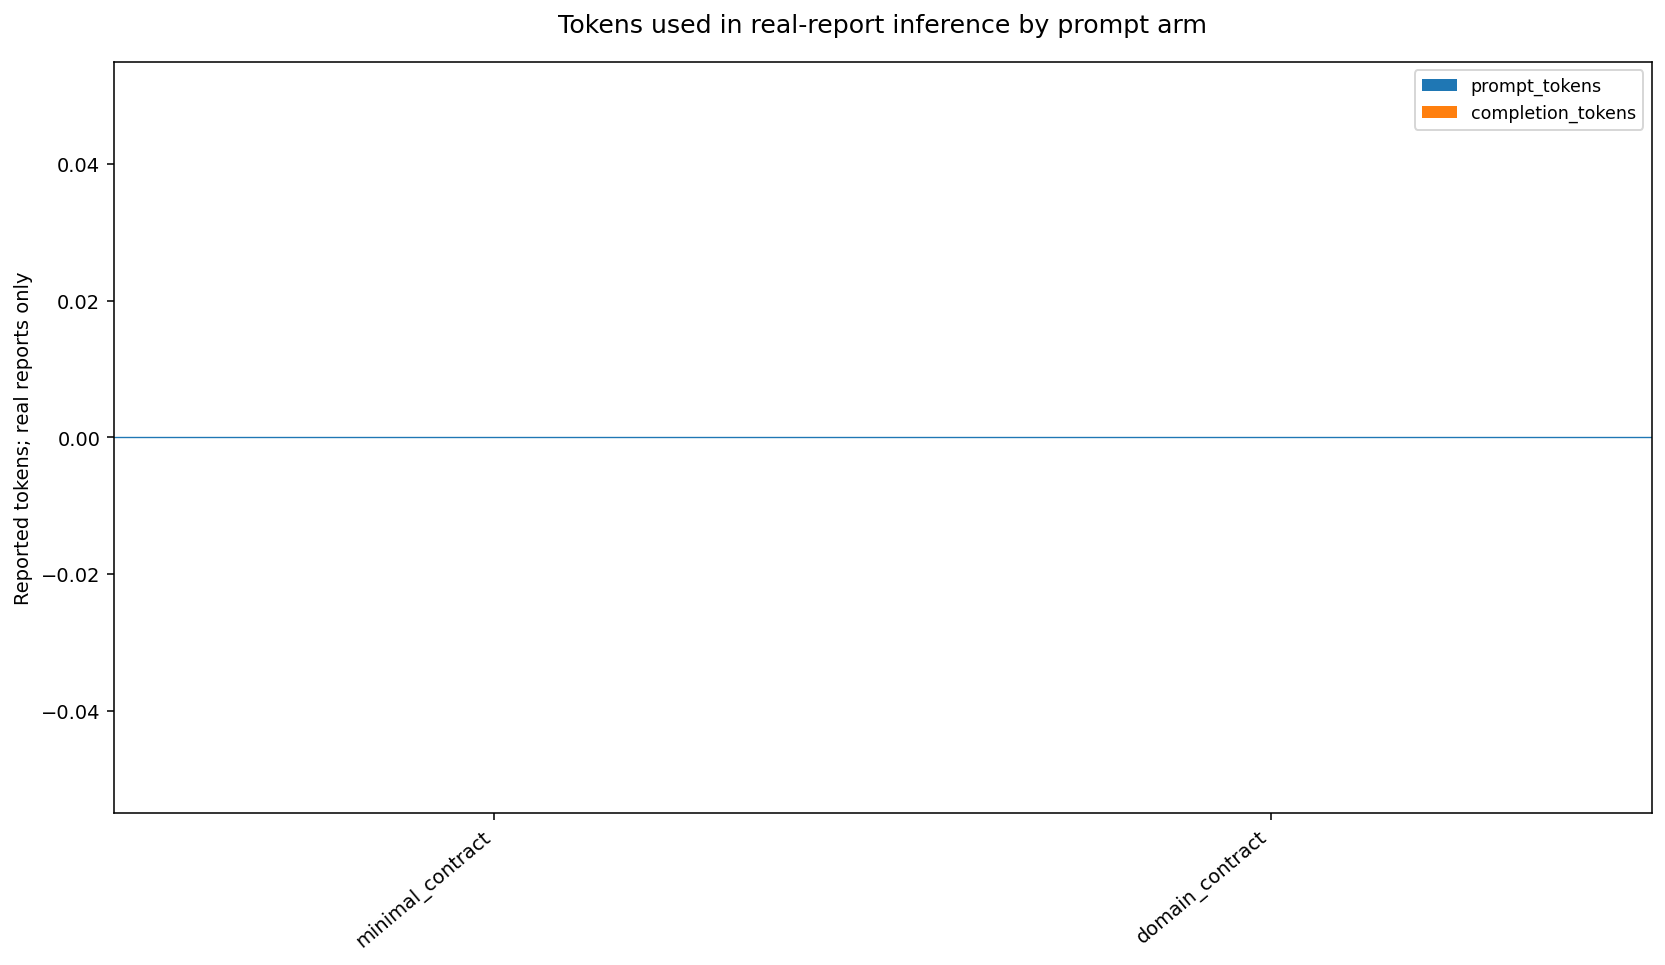

In [12]:
display_saved(10)


## 11. Measured inference time

Counts, assignment changes and software checks are not evidence of clinical accuracy or AUC improvement.


**Measured real-report generation time by prompt arm**

Measured generation times exclude server startup and token counting. Counterbalanced order does not eliminate warm-up effects.

Outcome: `blocked_canary`; common paired reports: 0

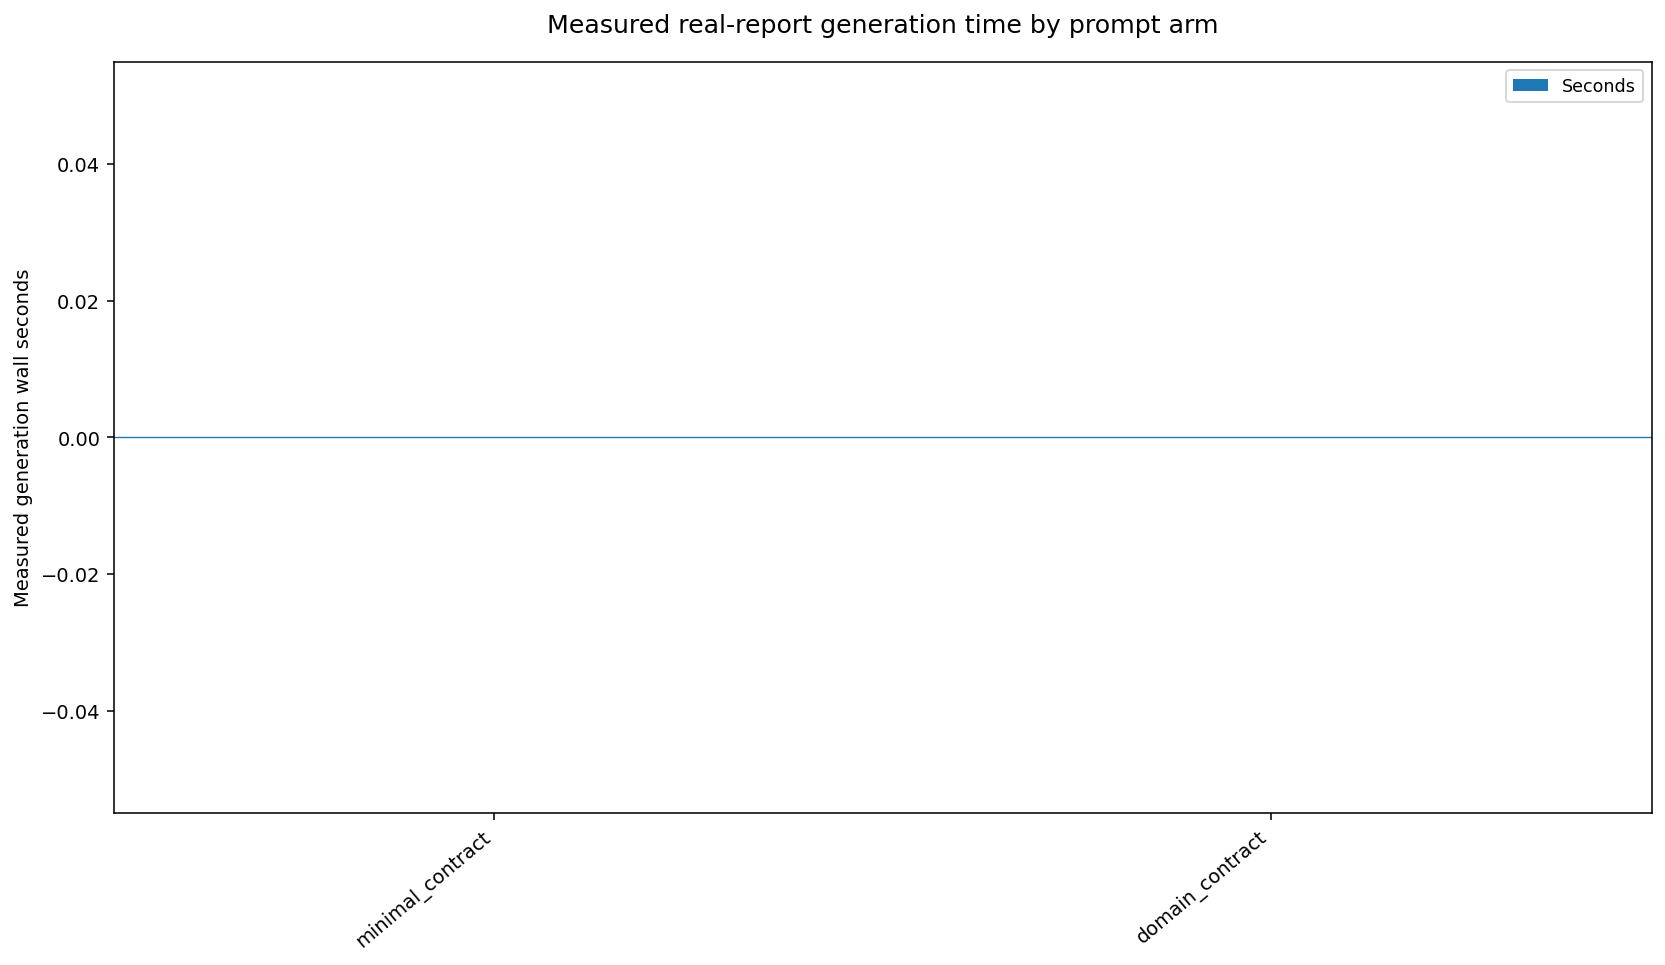

In [13]:
display_saved(11)


## 12. Protected evaluation and experiment accounting

Counts, assignment changes and software checks are not evidence of clinical accuracy or AUC improvement.


**Experiment accounting: inference calls and protected evaluation studies**

Checkpoint reuse must introduce zero new inference calls. All 58 expert studies and four report overlaps stay sealed.

Outcome: `blocked_canary`; common paired reports: 0

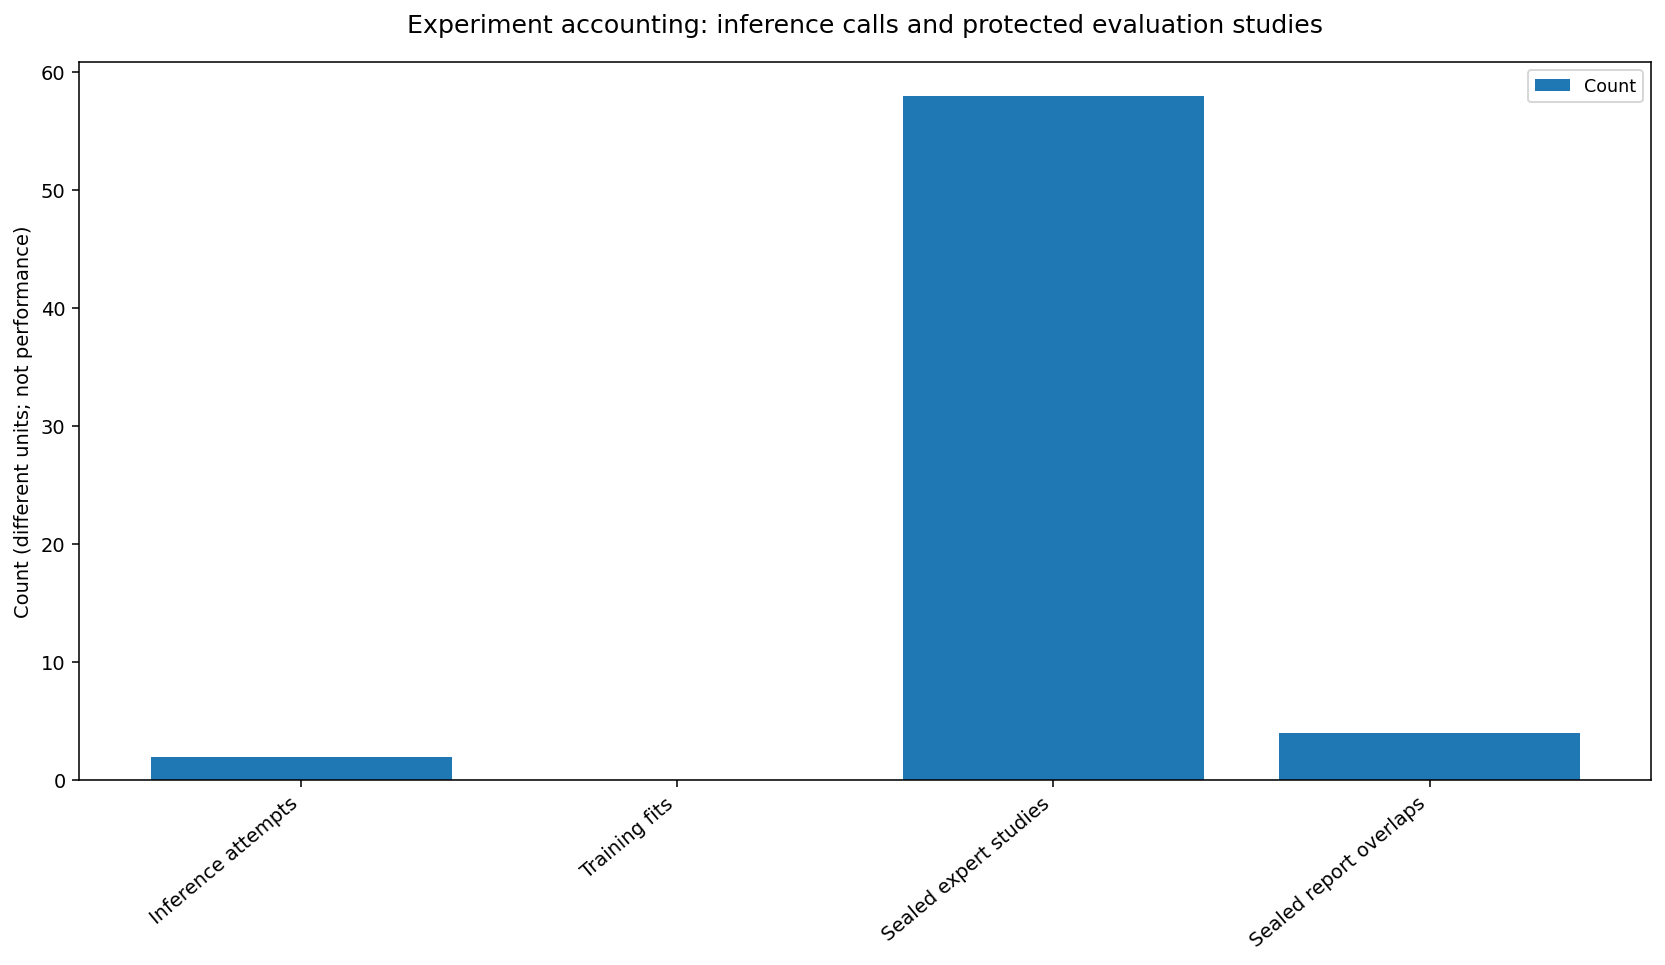

In [14]:
display_saved(12)


## Decision and handoff

Do not select the arm with more binary candidates as the winner. Inspect the recorded outcome and retain all candidate states as unapproved. A subsequent independent, original-language review is required before scaling target construction and before fitting an image model to these targets.

The next image representation experiments remain planned, not executed: matched plane/contrast additions and removals, then field-of-view and slice-context comparisons with the same encoder, split and training budget. Do not start those from this notebook.


In [15]:
finalize_figures()
DIRECTORY, summary = current_run()
assert summary["training_targets_approved"] is False
assert summary["official_auc"] is None and summary["model_fits"] == 0
print("TEACHER_PILOT_RECORDED")
print("Outcome:", summary["status"], "| Ground-truth accuracy: not measured | Image AUC: not measured")
print("Save with Ctrl+S, close, reopen and verify twelve PNG charts.")
print("Then run: python research/teacher/run.py collect")


TEACHER_PILOT_RECORDED
Outcome: blocked_canary | Ground-truth accuracy: not measured | Image AUC: not measured
Save with Ctrl+S, close, reopen and verify twelve PNG charts.
Then run: python research/teacher/run.py collect
